In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd
import os

# ---------------------------------------------------------------
# 1.1  Helper – Load Experiment from .npz files
# ---------------------------------------------------------------

def load_experiment(fp: Path) -> dict:
    """
    Load a *.npz file created by the pre-processing notebook
    and return a dict suitable for numerical analysis.

    Returns
    -------
    sample : dict
        ├─ "signals" : pd.DataFrame
        │             index = time [s]
        │             columns = time, 
        │                       incident_raw, reflected_raw, transmitted_raw,
        │                       incident_weight, reflected_weight, transmitted_weight   (whichever exist)
        ├─ "L0_mm"   : float  (if present)
        ├─ "A0_mm2"  : float  (if present)
        └─ "D0_mm"   : float  (if present)
    """
    with np.load(fp, allow_pickle=False) as data:
        # ---------- continuous signals -------------------------------------
        required = ["time"]
        continuous = [
            "time", "incident_raw", "reflected_raw", "transmitted_raw",
            "incident_weight", "reflected_weight", "transmitted_weight",
        ]
        # sanity check
        for key in required:
            if key not in data:
                raise KeyError(f"{key} missing from {fp.name}")

        df   = pd.DataFrame(dtype=np.float32)

        for key in continuous:
            if key in data:
                df[key] = data[key].astype(np.float32)

        sample: dict[str, object] = {"signals": df}

        # ---------- specimen / bar geometry --------------------------------
        for gk in ("L0_mm", "A0_mm2", "D0_mm"):
            if gk in data:
                # np.load can return 0-D arrays; convert to python float
                sample[gk] = float(np.asarray(data[gk]))

        # --- Tags (strings) ----------------------------------------------------
        tag_keys = [
            "uid",
            "material",
            "processing",
            "test_mode",
            "test_date",
            "test_temperature",
            "test_id",
        ]
        sample["tags"] = {tk: str(data[tk]) for tk in tag_keys if tk in data}

    return sample

# ---------------------------------------------------------------
# 1.2  Helper – cumulative (rectangle-rule) integral
# ---------------------------------------------------------------
def cumulative_integral(y: np.ndarray, dt: np.ndarray) -> np.ndarray:
    """
    Rectangle-rule ∫ y dt from t=0 to t_i, same shape as y.
    Assumes y.shape == dt.shape == (T,) or (B,T).
    """
    dt = np.diff(time, axis=-1)
    pad = np.zeros_like(time[..., :1])
    dt  = np.concatenate([dt, pad], axis=-1)   # pad so shapes match
    return np.cumsum(y * dt, axis=-1)


..\pinn_dataset\SS316A356\npz\DKS_20250507_SS316A356_LAB_RT_034.npz


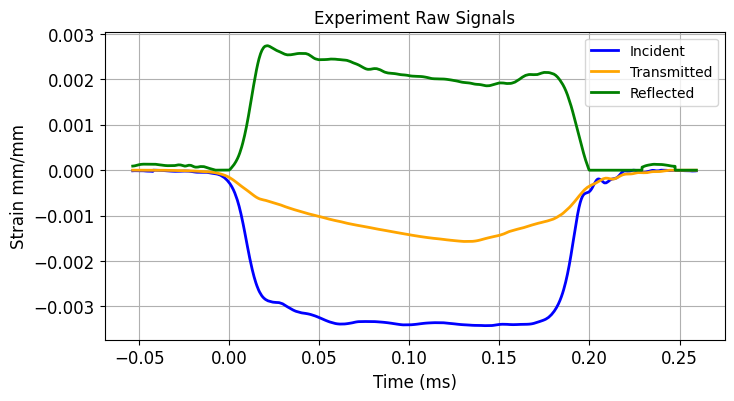

Specimen Cross-Section: 30.876 mm^2
Specimen Length: 6.360 mm


In [2]:
# --- 2.1  Load example experiment -------------------------------
data_dir = Path("../pinn_dataset/SS316A356/npz")
files    = sorted(data_dir.glob("*.npz"))
idx = 5

data = load_experiment(files[idx]) # change to desired idx
print(files[idx])

# quick data inspection
plt.figure(figsize=(8,4))
plt.plot(data["signals"]["time"], data["signals"]["incident_raw"], label = "Incident", lw = 2, c = "b")
plt.plot(data["signals"]["time"], data["signals"]["transmitted_raw"], label = "Transmitted", lw = 2, c = "orange")
plt.plot(data["signals"]["time"], data["signals"]["reflected_raw"], label = "Reflected", lw = 2, c = "g")
plt.title("Experiment Raw Signals")
plt.xlabel("Time (ms)", fontsize = 12) ; plt.ylabel("Strain mm/mm", fontsize = 12)
plt.xticks(fontsize = 12) ; plt.yticks(fontsize = 12)
plt.grid() ; plt.legend()
plt.show()

print(f"Specimen Cross-Section: {data['A0_mm2']:.3f} mm^2")
print(f"Specimen Length: {data['L0_mm']:.3f} mm")

In [3]:
# Bar Constants
E_bar  = 199.99   # GPa
c_bar  = 4953.321 # mm/ms
rho_bar= 7.8e-6   # kg/mm^3
bar_cross = 71.26 # mm²

In [4]:
result_dir = Path("../lsdyna_initalvel/SS316A356")

for file in files:
    data = load_experiment(file) # change to desired idx
    
    initial_vel = c_bar * data["signals"]["incident_raw"].astype(np.float32)    
    time = data["signals"]["time"].astype(np.float32)
    time_0 = np.where(time == 0)[0][0]  

    initial_vel = initial_vel[time_0:]
    time = time[time_0:]

    
    initial_vel_df = pd.DataFrame(data = {"Time":time, "X-vel":initial_vel}) 
    initial_vel_df.set_index("Time", inplace=True)

    file_name = f"{data['tags']['uid'][13:]}_inc_vel.csv"
    os.makedirs(result_dir, exist_ok = True)
    initial_vel_df.to_csv(os.path.join(result_dir, file_name))